# netML Malware Detection — No Docker end-to-end notebook (explicit models)

This notebook trains and evaluates the 4 models on the netML Malware Detection dataset:

- Logistic Regression  
- Linear SVM  
- Kernel SVM (RBF)  
- Random Forest  

It uses **lightweight flow/time-window features** extracted directly from each per-sample `.pcap` (first `N_PKTS` packets).

## Labels

From filename: `<id>_<binary>_<family>.pcap`
- **binary**: `benign` vs `malware` (easy task)
- **family**: `emotet`, `trickster`, ... or `benign` (hard task)

## Metric
Primary: **Balanced Accuracy** (as per dataset guidance)
Secondary: F1-macro, ROC-AUC (binary), confusion matrices, per-family results


In [2]:
from pathlib import Path
import os, sys, platform
import numpy as np
import pandas as pd

PROJECT_DIR = Path.cwd().resolve()
PCAP_DIR = PROJECT_DIR / "netml_malware_pcaps"

print("PROJECT_DIR:", PROJECT_DIR)
print("PCAP_DIR:", PCAP_DIR, "exists?", PCAP_DIR.exists())
print("Python:", sys.version.split()[0], "| Executable:", sys.executable)
print("Platform:", platform.platform())

assert PCAP_DIR.exists(), f"Missing folder: {PCAP_DIR}"


PROJECT_DIR: C:\Users\Jeffr\course-project-jeffreyliu20\final
PCAP_DIR: C:\Users\Jeffr\course-project-jeffreyliu20\final\netml_malware_pcaps exists? True
Python: 3.11.9 | Executable: c:\Users\Jeffr\course-project-jeffreyliu20\final\.venv\Scripts\python.exe
Platform: Windows-10-10.0.26200-SP0


## 1) Index PCAPs + parse labels from filenames

In [6]:
pcaps = sorted(PCAP_DIR.glob("*.pcap"))
print("PCAP count:", len(pcaps))
assert len(pcaps) > 0, f"No .pcap files found in {PCAP_DIR}"

def parse_labels_from_name(name: str):
    # name like: <id>_malware_emotet.pcap or <id>_benign_benign.pcap
    stem = Path(name).stem
    toks = stem.split("_")
    if len(toks) < 3:
        return None
    sample_id = toks[0]
    binary = toks[1]
    family = "_".join(toks[2:])
    return sample_id, binary, family

rows = []
bad = 0
for p in pcaps:
    parsed = parse_labels_from_name(p.name)
    if parsed is None:
        bad += 1
        continue
    sample_id, binary, family = parsed
    rows.append({"path": str(p), "file": p.name, "id": sample_id, "binary": binary, "family": family})

df = pd.DataFrame(rows)
print("Parsed rows:", len(df), "| Unparsable:", bad)
df["y_easy"] = (df["binary"] == "malware").astype(int)  # 1=malware, 0=benign
print(df.head())


PCAP count: 498446
Parsed rows: 498446 | Unparsable: 0
                                                path  \
0  C:\Users\Jeffr\course-project-jeffreyliu20\fin...   
1  C:\Users\Jeffr\course-project-jeffreyliu20\fin...   
2  C:\Users\Jeffr\course-project-jeffreyliu20\fin...   
3  C:\Users\Jeffr\course-project-jeffreyliu20\fin...   
4  C:\Users\Jeffr\course-project-jeffreyliu20\fin...   

                                         file                    id   binary  \
0    10000002068136406352_malware_emotet.pcap  10000002068136406352  malware   
1     10000026091954898561_bengin_benign.pcap  10000026091954898561   bengin   
2  10000037800371447645_malware_ccleaner.pcap  10000037800371447645  malware   
3   10000113156724180745_malware_artemis.pcap  10000113156724180745  malware   
4     1000016327458587213_malware_adload.pcap   1000016327458587213  malware   

     family  y_easy  
0    emotet       1  
1    benign       0  
2  ccleaner       1  
3   artemis       1  
4    adload      

## 2) Feature extraction (first `N_PKTS` packets per sample)

We compute a tabular feature vector per `.pcap`:

- packet length sequence: `pkt_len_1..pkt_len_N`
- inter-arrival time sequence: `iat_1..iat_{N-1}`
- summary stats (count/bytes/duration/means/stds/min/max)
- TCP flag counts (SYN/ACK/FIN/RST/PSH/URG) for first `N_PKTS`

This is a practical approximation of “flow/time-window statistics” (pcapML-style) and is fast to run.


In [7]:
import dpkt
from joblib import Parallel, delayed
import numpy as np

N_PKTS = 10                 # match the "top-N packets" idea
N_JOBS = max(1, (os.cpu_count() or 2) // 2)  # adjust if needed
CACHE_PATH = PROJECT_DIR / f"features_flowstats_N{N_PKTS}.parquet"

def _open_pcap_reader(fh):
    # dpkt can read pcap and pcapng; try pcap then fallback to pcapng
    try:
        return dpkt.pcap.Reader(fh), "pcap"
    except (ValueError, dpkt.dpkt.NeedData):
        fh.seek(0)
        return dpkt.pcapng.Reader(fh), "pcapng"

def extract_features_one(path: str, n_pkts: int = N_PKTS):
    try:
        with open(path, "rb") as fh:
            reader, _ = _open_pcap_reader(fh)
            ts_list = []
            lens = []
            tcp_flags = {"syn":0,"ack":0,"fin":0,"rst":0,"psh":0,"urg":0}
            tcp_ct = udp_ct = other_ct = 0
            total_bytes = 0

            for i, (ts, buf) in enumerate(reader):
                if i >= n_pkts:
                    break
                ts_list.append(float(ts))
                blen = len(buf)
                lens.append(blen)
                total_bytes += blen

                try:
                    eth = dpkt.ethernet.Ethernet(buf)
                    ip = eth.data
                    if isinstance(ip, (dpkt.ip.IP, dpkt.ip6.IP6)):
                        l4 = ip.data
                        if isinstance(l4, dpkt.tcp.TCP):
                            tcp_ct += 1
                            flags = int(l4.flags)
                            if flags & dpkt.tcp.TH_SYN: tcp_flags["syn"] += 1
                            if flags & dpkt.tcp.TH_ACK: tcp_flags["ack"] += 1
                            if flags & dpkt.tcp.TH_FIN: tcp_flags["fin"] += 1
                            if flags & dpkt.tcp.TH_RST: tcp_flags["rst"] += 1
                            if flags & dpkt.tcp.TH_PUSH: tcp_flags["psh"] += 1
                            if flags & dpkt.tcp.TH_URG: tcp_flags["urg"] += 1
                        elif isinstance(l4, dpkt.udp.UDP):
                            udp_ct += 1
                        else:
                            other_ct += 1
                    else:
                        other_ct += 1
                except Exception:
                    pass

            lens = lens[:n_pkts]
            while len(lens) < n_pkts:
                lens.append(0)

            iats = []
            for a, b in zip(ts_list, ts_list[1:]):
                iats.append(max(0.0, b - a))
            iats = iats[:max(0, n_pkts-1)]
            while len(iats) < max(0, n_pkts-1):
                iats.append(0.0)

            n_seen = len(ts_list)
            duration = (ts_list[-1] - ts_list[0]) if n_seen >= 2 else 0.0

            lens_arr = np.array([x for x in lens if x > 0], dtype=float)
            iat_arr  = np.array([x for x in iats if x > 0], dtype=float)

            def safe_stats(arr):
                if arr.size == 0:
                    return (0.0, 0.0, 0.0, 0.0)
                return (float(arr.mean()), float(arr.std()), float(arr.min()), float(arr.max()))

            len_mean, len_std, len_min, len_max = safe_stats(lens_arr)
            iat_mean, iat_std, iat_min, iat_max = safe_stats(iat_arr)

            feats = {
                "n_pkts_used": float(n_seen),
                "total_bytes_used": float(total_bytes),
                "duration": float(duration),
                "len_mean": len_mean, "len_std": len_std, "len_min": len_min, "len_max": len_max,
                "iat_mean": iat_mean, "iat_std": iat_std, "iat_min": iat_min, "iat_max": iat_max,
                "tcp_ct": float(tcp_ct), "udp_ct": float(udp_ct), "other_ct": float(other_ct),
                **{f"tcp_{k}": float(v) for k, v in tcp_flags.items()},
            }

            for j in range(n_pkts):
                feats[f"pkt_len_{j+1}"] = float(lens[j])
            for j in range(n_pkts-1):
                feats[f"iat_{j+1}"] = float(iats[j])

            return feats, True, ""
    except Exception as e:
        return {}, False, str(e)

# Smoke test
for p in pcaps[:3]:
    feats, ok, err = extract_features_one(str(p), N_PKTS)
    print(p.name, "ok?", ok, "n_features:", len(feats), "err:", err[:120])


10000002068136406352_malware_emotet.pcap ok? True n_features: 39 err: 
10000026091954898561_bengin_benign.pcap ok? True n_features: 39 err: 
10000037800371447645_malware_ccleaner.pcap ok? True n_features: 39 err: 


## 3) Build (or load) the feature matrix

In [8]:
if CACHE_PATH.exists():
    print("Loading cached features:", CACHE_PATH)
    feat_df = pd.read_parquet(CACHE_PATH)
else:
    paths = df["path"].tolist()

    results = Parallel(n_jobs=N_JOBS, prefer="processes")(
        delayed(extract_features_one)(p, N_PKTS) for p in tqdm(paths, total=len(paths))
    )

    feat_rows = []
    ok_ct = 0
    for (feats, ok, err), meta in zip(results, df.to_dict("records")):
        if not ok:
            continue
        ok_ct += 1
        feats = dict(feats)
        feats["file"] = meta["file"]
        feat_rows.append(feats)

    feat_df = pd.DataFrame(feat_rows)
    print("OK feature rows:", ok_ct, "out of", len(df))

    feat_df = feat_df.merge(df[["file", "y_easy", "family"]], on="file", how="left")
    feat_df.to_parquet(CACHE_PATH, index=False)
    print("Saved cache:", CACHE_PATH)

print("Feature DF shape:", feat_df.shape)
feat_df.head()


Loading cached features: c:\Users\Jeffr\course-project-jeffreyliu20\final\features_flowstats_N10.parquet
Feature DF shape: (498446, 42)


,n_pkts_used,total_bytes_used,duration,len_mean,len_std,len_min,len_max,iat_mean,iat_std,iat_min,...,iat_3,iat_4,iat_5,iat_6,iat_7,iat_8,iat_9,file,y_easy,family
0,6.0,374.0,1.063545,62.333333,2.687419,60.0,66.0,0.212709,0.231730,0.023415,...,0.023547,0.497487,0.023415,0.000000,0.000000,0.000000,0.000000,10000002068136406352_malware_emotet.pcap,1,emotet
1,4.0,834.0,218.619244,208.500000,179.538993,74.0,515.0,72.873081,102.855270,0.010692,...,0.010692,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10000026091954898561_bengin_benign.pcap,0,benign
2,2.0,210.0,0.018831,105.000000,26.000000,79.0,131.0,0.018831,0.000000,0.018831,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10000037800371447645_malware_ccleaner.pcap,1,ccleaner
3,10.0,3040.0,0.027925,304.000000,446.435886,54.0,1500.0,0.003103,0.005722,0.000039,...,0.000435,0.000141,0.007658,0.000039,0.000204,0.017926,0.000929,10000113156724180745_malware_artemis.pcap,1,artemis
4,2.0,132.0,0.419762,66.000000,0.000000,66.0,66.0,0.419762,0.000000,0.419762,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1000016327458587213_malware_adload.pcap,1,adload


## 4) Prepare matrices

In [9]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, f1_score

label_cols = {"file", "y_easy", "family"}
feature_cols = [c for c in feat_df.columns if c not in label_cols]

X = feat_df[feature_cols].to_numpy(dtype=np.float32)
y_easy = feat_df["y_easy"].to_numpy(dtype=int)
y_hard = feat_df["family"].astype(str).to_numpy()

print("X:", X.shape, "| y_easy:", y_easy.shape, "| y_hard:", y_hard.shape)
print("Easy class balance:", np.bincount(y_easy))

RANDOM_SEED = 1337


X: (498446, 39) | y_easy: (498446,) | y_hard: (498446,)
Easy class balance: [129121 369325]


In [10]:
print("rows:", len(feat_df))
print("unique files:", feat_df["file"].nunique())
print("top rows-per-file:\n", feat_df["file"].value_counts().head(10))

# exact duplicate feature rows (can inflate CV if duplicates split across folds)
dup_feat = feat_df.duplicated(subset=feature_cols).mean()
dup_feat_y = feat_df.duplicated(subset=feature_cols + ["y_easy"]).mean()
print(f"duplicate X rows fraction: {dup_feat:.6f}")
print(f"duplicate (X,y) rows fraction: {dup_feat_y:.6f}")

rows: 498446
unique files: 498446
top rows-per-file:
 file
10000002068136406352_malware_emotet.pcap      1
10000026091954898561_bengin_benign.pcap       1
10000037800371447645_malware_ccleaner.pcap    1
10000113156724180745_malware_artemis.pcap     1
1000016327458587213_malware_adload.pcap       1
10000168329093918222_benign_benign.pcap       1
10000337095817554822_malware_trickbot.pcap    1
10000358954602436484_malware_tinba.pcap       1
10000406413035525783_bengin_benign.pcap       1
10000446970923238640_malware_pua.pcap         1
Name: count, dtype: int64
duplicate X rows fraction: 0.022476
duplicate (X,y) rows fraction: 0.022456


## 5) Easy task — train/evaluate proposal models (5-fold CV)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.kernel_approximation import RBFSampler

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import (
    balanced_accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)

models_easy = {
    "LogReg": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            solver="lbfgs"
        )),
    ]),
    "LinearSVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LinearSVC(class_weight="balanced")),
    ]),
    # Kernel-SVM approximation via Random Fourier Features + LinearSVC
    "Kernel-SVM (RFF)": Pipeline([
        ("scaler", StandardScaler()),
        ("rff", RBFSampler(gamma=0.1, n_components=256, random_state=RANDOM_SEED)),
        ("clf", LinearSVC(class_weight="balanced")),
    ]),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_SEED,
        class_weight="balanced_subsample",
    ),
}


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
scoring = {"bal_acc": "balanced_accuracy", "f1": "f1"}

easy_results = []
for name, model in models_easy.items():
    print(f"\n=== {name} (5-fold CV) ===")
    out = cross_validate(model, X, y_easy, cv=cv, scoring=scoring, return_train_score=False)
    bal_mean, bal_std = out["test_bal_acc"].mean(), out["test_bal_acc"].std()
    f1_mean, f1_std = out["test_f1"].mean(), out["test_f1"].std()
    easy_results.append({
        "model": name,
        "balanced_acc_mean": bal_mean,
        "balanced_acc_std": bal_std,
        "f1_mean": f1_mean,
        "f1_std": f1_std,
    })
    print(f"Balanced Acc: {bal_mean:.4f} ± {bal_std:.4f}")
    print(f"F1:           {f1_mean:.4f} ± {f1_std:.4f}")

easy_results_df = pd.DataFrame(easy_results).sort_values("balanced_acc_mean", ascending=False)
display(easy_results_df)


=== LogReg (5-fold CV) ===
Balanced Acc: 0.9379 ± 0.0010
F1:           0.9511 ± 0.0007

=== LinearSVM (5-fold CV) ===
Balanced Acc: 0.9360 ± 0.0007
F1:           0.9478 ± 0.0005

=== Kernel-SVM (RFF) (5-fold CV) ===
Balanced Acc: 0.9682 ± 0.0002
F1:           0.9744 ± 0.0001

=== RandomForest (5-fold CV) ===
Balanced Acc: 0.9989 ± 0.0001
F1:           0.9994 ± 0.0001


,model,balanced_acc_mean,balanced_acc_std,f1_mean,f1_std
3,RandomForest,0.998937,0.000146,0.999400,0.000084
2,Kernel-SVM (RFF),0.968244,0.000158,0.974394,0.000099
0,LogReg,0.937930,0.000999,0.951124,0.000706
1,LinearSVM,0.935953,0.000725,0.947823,0.000548


In [ ]:
#shuffle to make sure models aren't overfitting
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
scoring_easy = {"bal_acc": "balanced_accuracy", "f1": "f1", "roc_auc": "roc_auc"}

model = models_easy["RandomForest"]

rng = np.random.default_rng(RANDOM_SEED)
y_shuf = rng.permutation(y_easy)

out = cross_validate(model, X, y_shuf, cv=cv, scoring=scoring_easy, n_jobs=-1)
print("Shuffled-label BA:", out["test_bal_acc"].mean(), "+/-", out["test_bal_acc"].std())
print("Shuffled-label AUC:", out["test_roc_auc"].mean(), "+/-", out["test_roc_auc"].std())


Shuffled-label BA: 0.4999400563037687 +/- 0.001074753207368409
Shuffled-label AUC: 0.49928814150228396 +/- 0.0021770425691329436



=== LogReg (holdout) ===


c:\Users\Jeffr\course-project-jeffreyliu20\final\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Holdout Balanced Acc: 0.9378 | F1: 0.9512 | ROC-AUC: 0.9708

=== LinearSVM (holdout) ===
Holdout Balanced Acc: 0.9366 | F1: 0.9484 | ROC-AUC: 0.9691

=== Kernel-SVM (RFF) (holdout) ===
Holdout Balanced Acc: 0.9686 | F1: 0.9745 | ROC-AUC: 0.9906

=== RandomForest (holdout) ===
Holdout Balanced Acc: 0.9989 | F1: 0.9994 | ROC-AUC: 0.9998


,model,holdout_balanced_acc,holdout_f1,holdout_roc_auc
3,RandomForest,0.998910,0.999364,0.999843
2,Kernel-SVM (RFF),0.968551,0.974484,0.990615
0,LogReg,0.937788,0.951171,0.970797
1,LinearSVM,0.936646,0.948405,0.969069


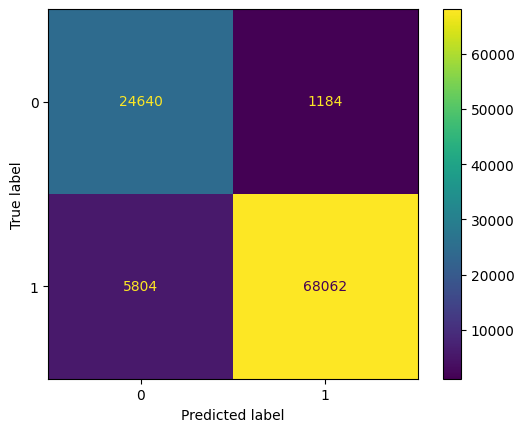

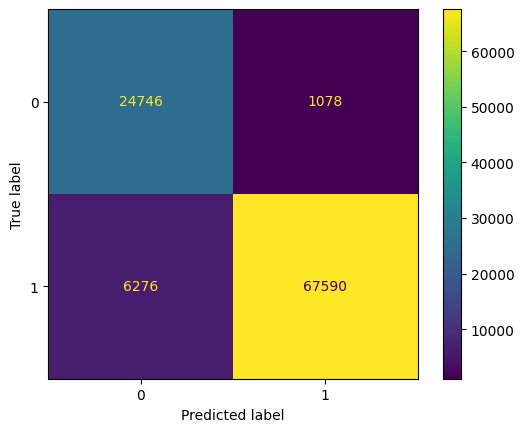

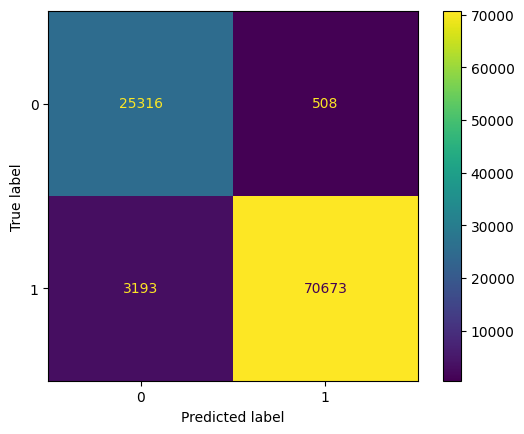

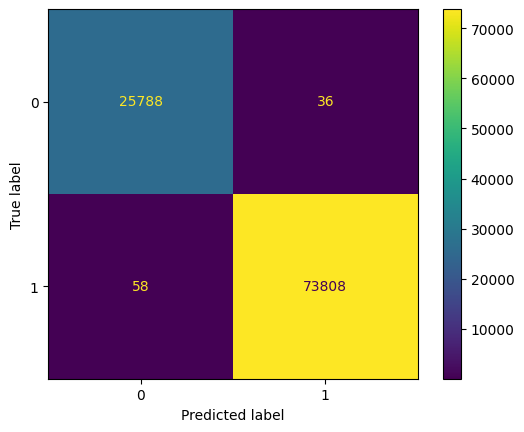

In [8]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y_easy, test_size=0.2, stratify=y_easy, random_state=RANDOM_SEED
)

artifact_rows = []
for name, model in models_easy.items():
    print(f"\n=== {name} (holdout) ===")
    model.fit(X_tr, y_tr)

    # Confusion matrix
    y_hat = model.predict(X_te)
    cm = confusion_matrix(y_te, y_hat)
    ConfusionMatrixDisplay(cm).plot()

    # ROC-AUC needs scores (prob or decision function)
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X_te)[:, 1]
    else:
        # LinearSVC / RFF+LinearSVC: decision_function is the right choice
        scores = model.decision_function(X_te)

    auc = roc_auc_score(y_te, scores)
    bal = balanced_accuracy_score(y_te, y_hat)
    f1 = f1_score(y_te, y_hat)

    artifact_rows.append({
        "model": name,
        "holdout_balanced_acc": bal,
        "holdout_f1": f1,
        "holdout_roc_auc": auc,
    })
    print(f"Holdout Balanced Acc: {bal:.4f} | F1: {f1:.4f} | ROC-AUC: {auc:.4f}")

artifact_df = pd.DataFrame(artifact_rows).sort_values("holdout_balanced_acc", ascending=False)
display(artifact_df)

## 6) Hard task — family classification (5-fold CV)

In [ ]:
cv_h = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# CV headline metrics (no huge out-of-fold prediction arrays)
scoring_hard = {
    "bal_acc": "balanced_accuracy",
    "f1_macro": "f1_macro",
}

hard_results = []
for name, model in models_easy.items():  # reuse same model set
    print(f"\n=== {name} (5-fold CV, hard 19-class) ===")
    out = cross_validate(
        model,
        X, y_hard,
        cv=cv_h,
        scoring=scoring_hard,
        return_train_score=False,
    )

    bal_mean, bal_std = out["test_bal_acc"].mean(), out["test_bal_acc"].std()
    f1m_mean, f1m_std = out["test_f1_macro"].mean(), out["test_f1_macro"].std()

    hard_results.append({
        "model": name,
        "balanced_acc_mean": bal_mean,
        "balanced_acc_std": bal_std,
        "f1_macro_mean": f1m_mean,
        "f1_macro_std": f1m_std,
    })

    print(f"Balanced Acc: {bal_mean:.4f} ± {bal_std:.4f}")
    print(f"F1-macro:     {f1m_mean:.4f} ± {f1m_std:.4f}")

hard_results_df = pd.DataFrame(hard_results).sort_values("balanced_acc_mean", ascending=False)
display(hard_results_df)


=== LogReg (5-fold CV, hard 19-class) ===
Balanced Acc: 0.5140 ± 0.0014
F1-macro:     0.3994 ± 0.0030

=== LinearSVM (5-fold CV, hard 19-class) ===
Balanced Acc: 0.4529 ± 0.0050
F1-macro:     0.3662 ± 0.0033

=== Kernel-SVM (RFF) (5-fold CV, hard 19-class) ===
Balanced Acc: 0.5525 ± 0.0032
F1-macro:     0.4654 ± 0.0020

=== RandomForest (5-fold CV, hard 19-class) ===
Balanced Acc: 0.6020 ± 0.0025
F1-macro:     0.6030 ± 0.0014


,model,balanced_acc_mean,balanced_acc_std,f1_macro_mean,f1_macro_std
3,RandomForest,0.601976,0.002463,0.603016,0.001412
2,Kernel-SVM (RFF),0.552469,0.003204,0.465366,0.002030
0,LogReg,0.513994,0.001425,0.399389,0.002983
1,LinearSVM,0.452929,0.004996,0.366154,0.003348



=== LogReg (holdout, hard) ===


c:\Users\Jeffr\course-project-jeffreyliu20\final\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


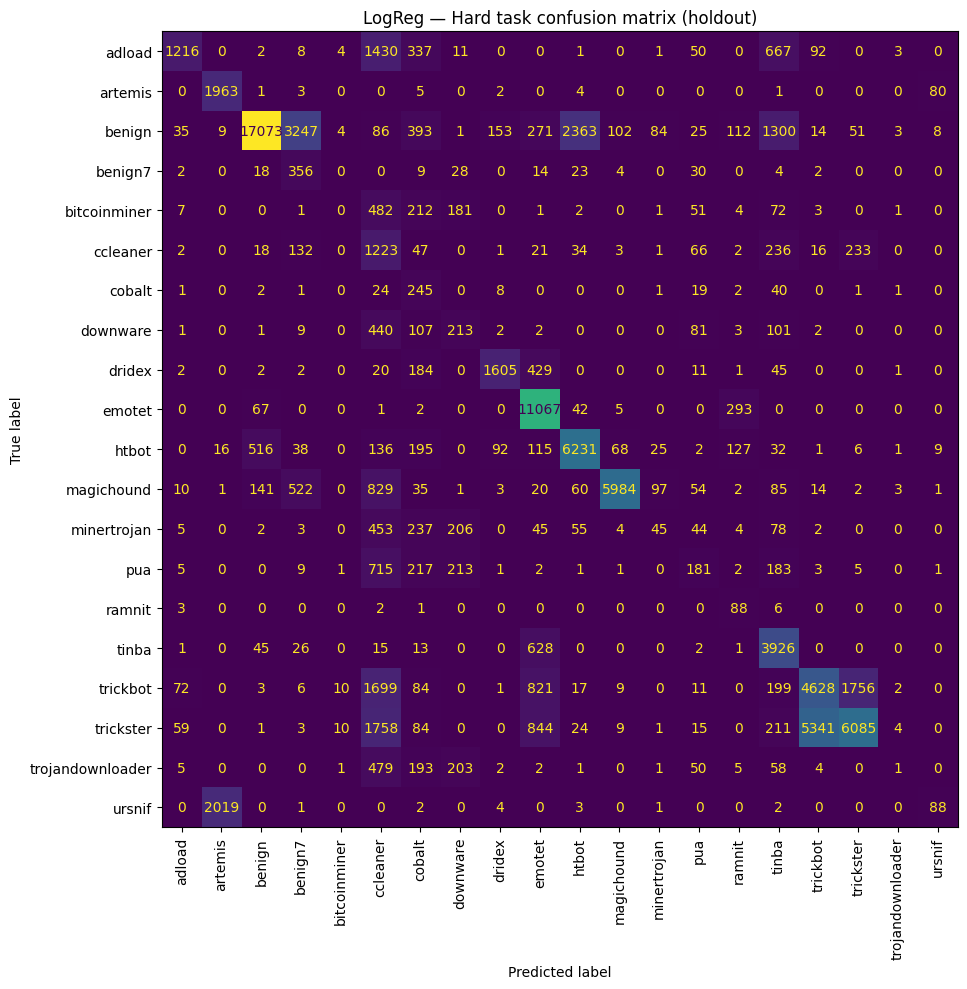


=== LinearSVM (holdout, hard) ===


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

from sklearn.base import clone
# Holdout split for HARD task (19-class)
X_tr_h, X_te_h, y_tr_h, y_te_h = train_test_split(
    X, y_hard,
    test_size=0.2,
    stratify=y_hard,
    random_state=RANDOM_SEED
)

# Stable class order for axes (so plots are comparable across models)
classes = np.unique(y_hard)

for name, model in models_easy.items():
    print(f"\n=== {name} (holdout, hard) ===")

    m = clone(model)          # fresh unfitted copy
    m.fit(X_tr_h, y_tr_h)
    y_hat = m.predict(X_te_h)

    cm = confusion_matrix(y_te_h, y_hat, labels=classes)

    fig, ax = plt.subplots(figsize=(10, 10))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes).plot(
        ax=ax,
        xticks_rotation=90,
        values_format="d",
        colorbar=False
    )
    ax.set_title(f"{name} — Hard task confusion matrix (holdout)")
    plt.tight_layout()
    plt.show()


=== RandomForest (holdout, hard) ===

=== Kernel-SVM (RFF) (holdout, hard) ===


c:\Users\Jeffr\course-project-jeffreyliu20\final\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


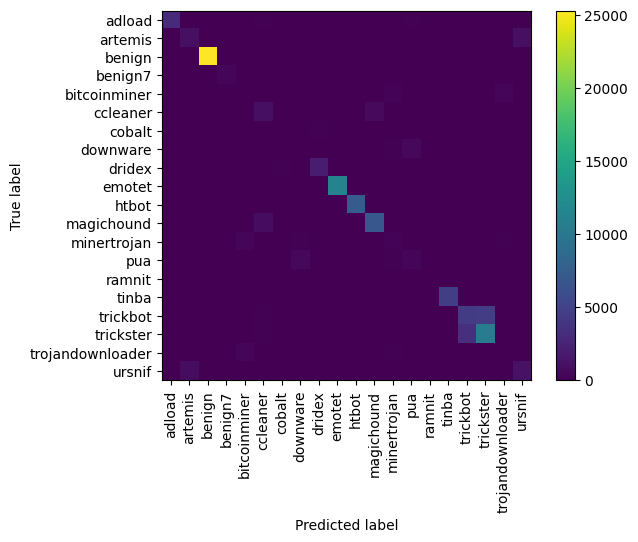

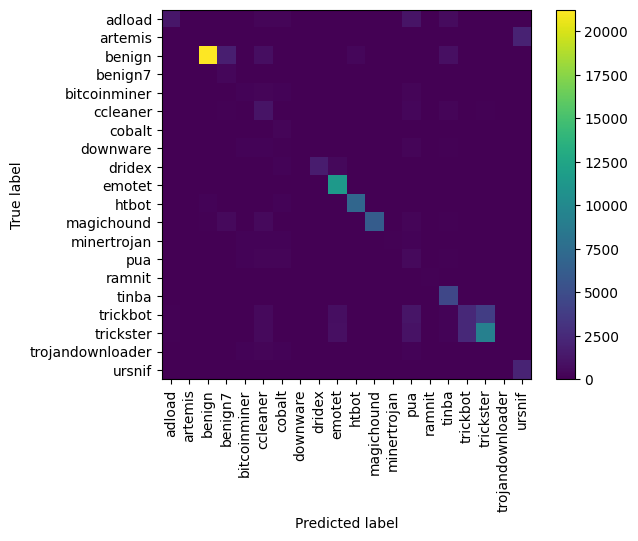

In [23]:
X_tr_h, X_te_h, y_tr_h, y_te_h = train_test_split(
    X, y_hard, test_size=0.2, stratify=y_hard, random_state=RANDOM_SEED
)

classes = np.array(sorted(np.unique(y_hard)))  # stable axis order

# choose which models you actually want CMs for
models_for_hard_cm = {
    "RandomForest": models_easy["RandomForest"],
    "Kernel-SVM (RFF)": models_easy["Kernel-SVM (RFF)"],
    # "LogReg": models_easy["LogReg"],  # optional
    # intentionally omit "LinearSVM"
}

for name, model in models_for_hard_cm.items():
    print(f"\n=== {name} (holdout, hard) ===")
    m = clone(model)
    m.fit(X_tr_h, y_tr_h)
    y_hat = m.predict(X_te_h)

    cm = confusion_matrix(y_te_h, y_hat, labels=classes)
    ConfusionMatrixDisplay(cm, display_labels=classes).plot(
        xticks_rotation=90,
        values_format="d",
        include_values=False,   # set True if you want the numbers (it’s very cluttered)
    )


=== RandomForest (holdout, hard) ===


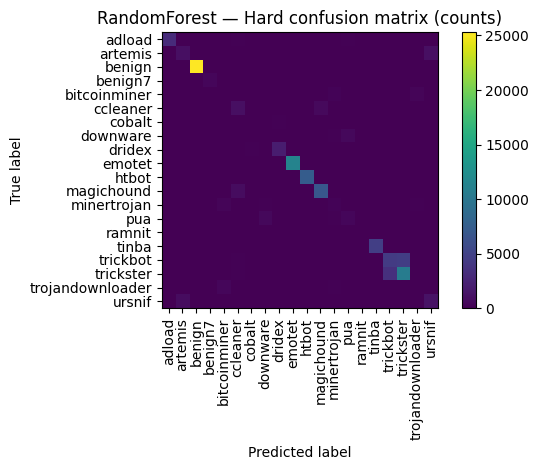

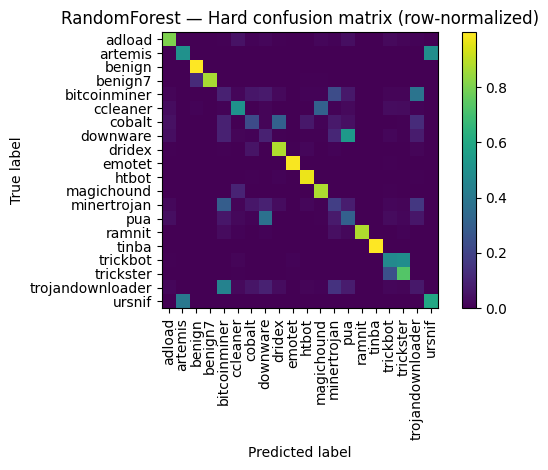


=== Kernel-SVM (RFF) (holdout, hard) ===


c:\Users\Jeffr\course-project-jeffreyliu20\final\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


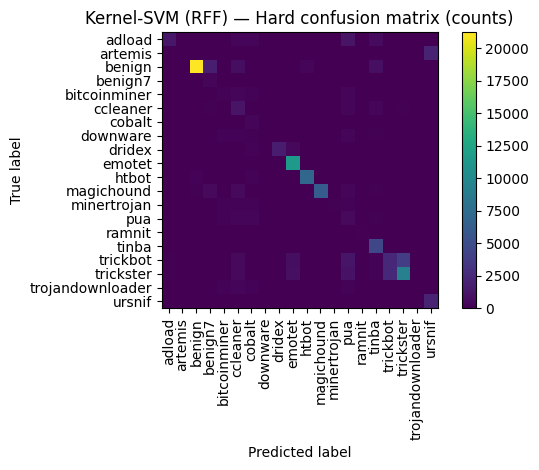

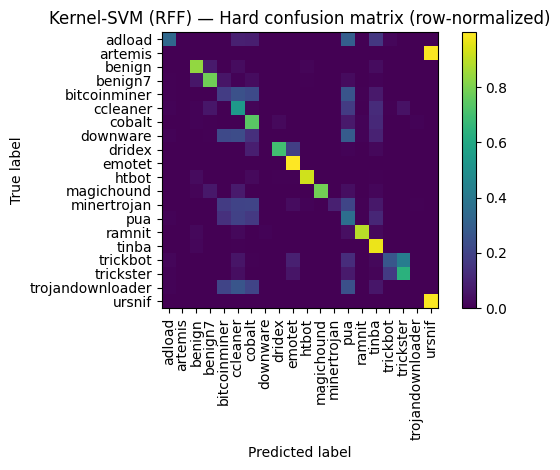

In [24]:
X_tr_h, X_te_h, y_tr_h, y_te_h = train_test_split(
    X, y_hard, test_size=0.2, stratify=y_hard, random_state=RANDOM_SEED
)

# Stable axis order
classes = np.array(sorted(np.unique(y_hard)))

# Only run the models you actually want matrices for (saves a LOT of time)
models_for_hard_cm = {
    "RandomForest": models_easy["RandomForest"],
    "Kernel-SVM (RFF)": models_easy["Kernel-SVM (RFF)"],
    # "LogReg": models_easy["LogReg"],  # optional baseline
    # Avoid LinearSVM here if it’s slow / not converging
}

for name, model in models_for_hard_cm.items():
    print(f"\n=== {name} (holdout, hard) ===")

    m = clone(model)   # fresh unfitted copy
    m.fit(X_tr_h, y_tr_h)
    y_hat = m.predict(X_te_h)

    # 1) Raw counts
    cm = confusion_matrix(y_te_h, y_hat, labels=classes)
    ConfusionMatrixDisplay(cm, display_labels=classes).plot(
        xticks_rotation=90,
        include_values=False
    )
    plt.title(f"{name} — Hard confusion matrix (counts)")
    plt.tight_layout()
    plt.show()

    # 2) Row-normalized (by true label)
    cm_norm = confusion_matrix(y_te_h, y_hat, labels=classes, normalize="true")
    ConfusionMatrixDisplay(cm_norm, display_labels=classes).plot(
        xticks_rotation=90,
        values_format=".2f",
        include_values=False
    )
    plt.title(f"{name} — Hard confusion matrix (row-normalized)")
    plt.tight_layout()
    plt.show()

## 7) Robustness — Family-held-out evaluation (binary)

For each malware family `F`:
- Train on: all benign + all malware families except `F`
- Test on: all benign + family `F`

Report mean balanced accuracy across held-out families.


In [26]:

families = sorted([f for f in feat_df["family"].astype(str).unique().tolist() if f != "benign"])
fam_arr  = feat_df["family"].astype(str).to_numpy()

rng = np.random.default_rng(RANDOM_SEED)
benign_idx = np.where(fam_arr == "benign")[0]

# pick a fixed benign holdout subset used for every family
benign_test_frac = 0.2
n_bt = max(1, int(len(benign_idx) * benign_test_frac))
benign_test_idx = rng.choice(benign_idx, size=n_bt, replace=False)
benign_test_mask = np.zeros(len(fam_arr), dtype=bool)
benign_test_mask[benign_test_idx] = True

def family_holdout_scores(model, X, y_bin, fam_arr, fam_list, benign_test_mask):
    scores = []
    for fam in fam_list:
        is_fam = (fam_arr == fam)

        test_mask  = is_fam | benign_test_mask
        train_mask = (~is_fam) & (~benign_test_mask)  # key change: benign test is excluded from train

        Xtr, ytr = X[train_mask], y_bin[train_mask]
        Xte, yte = X[test_mask],  y_bin[test_mask]

        # sanity: should contain both classes (0 benign, 1 malware)
        if len(np.unique(yte)) < 2:
            continue

        m = clone(model)
        m.fit(Xtr, ytr)
        yhat = m.predict(Xte)

        ba = balanced_accuracy_score(yte, yhat)
        scores.append((fam, ba))
    return scores

fh_results = []
for name, model in models_easy.items():
    scores = family_holdout_scores(model, X, y_easy, fam_arr, families, benign_test_mask)
    vals = [s for _, s in scores]
    fh_results.append({"model": name, "mean_balanced_acc": float(np.mean(vals)),
                       "min": float(np.min(vals)), "max": float(np.max(vals)),
                       "n_families_used": len(vals)})
    print(f"{name}: mean={np.mean(vals):.4f} min={np.min(vals):.4f} max={np.max(vals):.4f} (families={len(vals)})")

fh_results_df = pd.DataFrame(fh_results).sort_values("mean_balanced_acc", ascending=False)
fh_results_df


c:\Users\Jeffr\course-project-jeffreyliu20\final\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\Jeffr\course-project-jeffreyliu20\final\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\Jeffr\course-project-jeffreyliu20\final\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\Jeffr\course-project-jeffreyliu20\final\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n

LogReg: mean=0.9242 min=0.7755 max=0.9800 (families=18)
LinearSVM: mean=0.9127 min=0.5967 max=0.9802 (families=18)
Kernel-SVM (RFF): mean=0.9239 min=0.6113 max=0.9889 (families=18)
RandomForest: mean=0.9874 min=0.8699 max=0.9995 (families=18)


,model,mean_balanced_acc,min,max,n_families_used
3,RandomForest,0.987382,0.869884,0.999507,18
0,LogReg,0.924204,0.775520,0.979998,18
2,Kernel-SVM (RFF),0.923888,0.611263,0.988890,18
1,LinearSVM,0.912683,0.596682,0.980249,18


In [ ]:
from sklearn.metrics import recall_score  # macro recall == balanced accuracy

# Build the holdout list as malware families only (prevents "benign7" issues)
malware_families = sorted(
    feat_df.loc[(feat_df["y_easy"] == 1) & (feat_df["family"] != "benign"), "family"].unique().tolist()
)

families_arr = feat_df["family"].astype(str).to_numpy()
y_easy_arr   = feat_df["y_easy"].to_numpy(dtype=int)

def family_holdout_scores_binary(model, X, y_easy, fam_arr, malware_fams):
    scores = []
    is_benign = (y_easy == 0)  # IMPORTANT: benign is defined by the binary label, not by family string

    for fam in malware_fams:
        is_fam = (fam_arr == fam)

        test_mask  = is_benign | is_fam          # all benign + this held-out malware family
        train_mask = ~is_fam                     # benign + all other malware families

        Xtr, ytr = X[train_mask], y_easy[train_mask]
        Xte, yte = X[test_mask],  y_easy[test_mask]

        m = clone(model).fit(Xtr, ytr)
        yhat = m.predict(Xte)

        # macro recall over labels [0,1] == balanced accuracy, and avoids the warning
        ba = recall_score(yte, yhat, labels=[0, 1], average="macro", zero_division=0)
        scores.append((fam, float(ba)))

    return scores


## 8) Save results

In [11]:
out_dir = PROJECT_DIR / "results"
out_dir.mkdir(exist_ok=True)

easy_results_df.to_csv(out_dir / "easy_cv_results.csv", index=False)
hard_results_df.to_csv(out_dir / "hard_cv_results.csv", index=False)
fh_results_df.to_csv(out_dir / "family_holdout_results.csv", index=False)

print("Wrote:")
print(" -", out_dir / "easy_cv_results.csv")
print(" -", out_dir / "hard_cv_results.csv")
print(" -", out_dir / "family_holdout_results.csv")


Wrote:
 - C:\Users\Jeffr\course-project-jeffreyliu20\final\results\easy_cv_results.csv
 - C:\Users\Jeffr\course-project-jeffreyliu20\final\results\hard_cv_results.csv
 - C:\Users\Jeffr\course-project-jeffreyliu20\final\results\family_holdout_results.csv


[easy_binary] LogReg (C=0.1)


c:\Users\Jeffr\course-project-jeffreyliu20\final\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[easy_binary] LogReg (C=1)


c:\Users\Jeffr\course-project-jeffreyliu20\final\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[easy_binary] LogReg (C=10)


...

c:\Users\Jeffr\course-project-jeffreyliu20\final\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[hard_19class] LogReg (C=10)


c:\Users\Jeffr\course-project-jeffreyliu20\final\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[hard_19class] RandomForest (n_estimators=10)
[hard_19class] RandomForest (n_estimators=50)
[hard_19class] RandomForest (n_estimators=100)


,task,feature_file_mb,model_family,sweep,balanced_acc,fit_s,predict_s,total_s,proc_cpu_pct,peak_rss_delta_mb,model_mb,rss_end_mb
0,easy_binary,53.746301,LogReg,C=0.1,0.885882,35.063996,0.012058,35.076129,328.036480,124.738281,0.000871,1848.054688
2,easy_binary,53.746301,LogReg,C=10,0.886243,35.442980,0.014768,35.457808,348.962275,124.738281,0.000870,2097.531250
1,easy_binary,53.746301,LogReg,C=1,0.883710,35.981006,0.012037,35.993113,341.645217,124.738281,0.000860,1972.792969
3,easy_binary,53.746301,RandomForest,n_estimators=10,0.999052,0.939380,0.016861,0.956297,759.766340,0.000000,0.281225,1723.363281
4,easy_binary,53.746301,RandomForest,n_estimators=50,0.998936,3.491098,0.039876,3.531032,1851.884132,1.453125,1.427700,1724.136719
5,easy_binary,53.746301,RandomForest,n_estimators=100,0.998937,6.648527,0.061778,6.710371,2065.832097,0.687500,2.864029,1724.312500
7,hard_19class,53.746301,LogReg,C=1,0.217023,261.881929,0.023284,261.905301,256.658847,124.738281,0.006551,1973.843750
6,hard_19class,53.746301,LogReg,C=0.1,0.242489,262.204859,0.018931,262.223880,243.911329,124.750000,0.006557,1849.105469
8,hard_19class,53.746301,LogReg,C=10,0.247982,263.946227,0.018946,263.965267,246.883807,0.000000,0.006554,1140.332031
9,hard_19class,53.746301,RandomForest,n_estimators=10,0.593731,1.895031,0.074506,1.969614,729.045281,0.000000,16.049806,948.691406


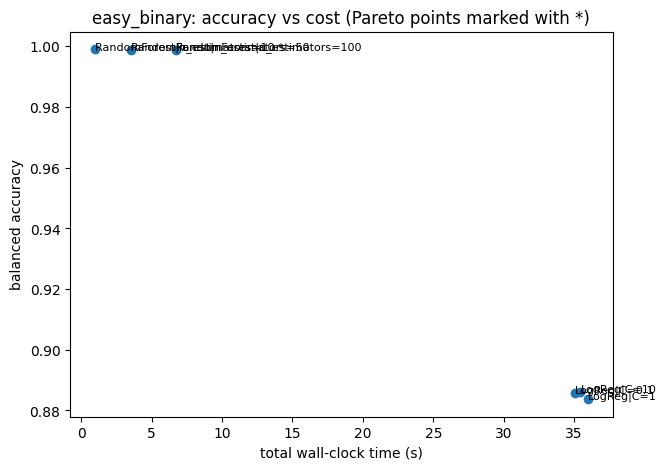

,task,feature_file_mb,model_family,sweep,balanced_acc,fit_s,predict_s,total_s,proc_cpu_pct,peak_rss_delta_mb,model_mb,rss_end_mb,is_pareto
0,easy_binary,53.746301,RandomForest,n_estimators=10,0.999052,0.93938,0.016861,0.956297,759.76634,0.0,0.281225,1723.363281,True


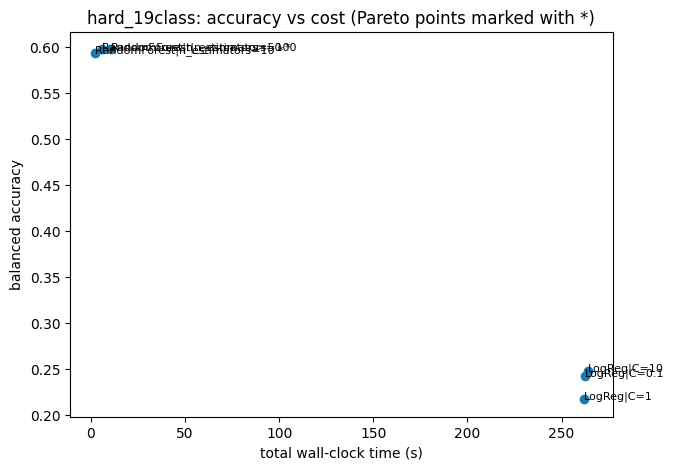

,task,feature_file_mb,model_family,sweep,balanced_acc,fit_s,predict_s,total_s,proc_cpu_pct,peak_rss_delta_mb,model_mb,rss_end_mb,is_pareto
0,hard_19class,53.746301,RandomForest,n_estimators=10,0.593731,1.895031,0.074506,1.969614,729.045281,0.000000,16.049806,948.691406,True
1,hard_19class,53.746301,RandomForest,n_estimators=50,0.597700,5.618334,0.194277,5.812694,1618.494479,906.941406,80.269210,1675.589844,True


In [33]:
# --- Systems-cost + accuracy benchmarking (ONE CELL) ---
import os, time, tempfile
for v in ["X", "y_easy", "y_hard"]:
    if v not in globals():
        raise NameError(f"Expected `{v}` to exist. Run your data-load cell first.")

RANDOM_SEED = globals().get("RANDOM_SEED", 1337)

# ---------- optional: feature file size (if present) ----------
PROJECT_DIR = globals().get("PROJECT_DIR", Path.cwd())
FEATURE_PATH = PROJECT_DIR / "features_flowstats_N10.parquet"
feature_file_mb = (FEATURE_PATH.stat().st_size / (1024**2)) if FEATURE_PATH.exists() else np.nan

# ---------- knobs (edit these if you want fewer runs) ----------
LOGREG_C_LIST = [0.1, 1.0, 10.0]
RF_NEST_LIST   = [10, 50, 100]          # keep modest; large forests explode artifact size
TEST_SIZE = 0.2

RUN_EASY = True
RUN_HARD = True

# If artifact-dumping is too slow or too large on disk, flip this False.
MEASURE_MODEL_ARTIFACT_MB = True

# ---------- helpers ----------
def _measure_fit_predict(estimator, Xtr, ytr, Xte):
    """
    Returns dict with fit/predict time, process CPU%, peak RSS delta (MB), and optionally model artifact size (MB).
    """
    import psutil
    proc = psutil.Process(os.getpid())

    rss0 = proc.memory_info().rss
    cpu0 = proc.cpu_times()
    t0 = time.perf_counter()

    # simple RSS peak sampling (cheap, avoids heavy profilers)
    peak_rss = rss0
    # sample a few times during fit+predict; you can increase samples if you want
    def sample_rss():
        nonlocal peak_rss
        rss = proc.memory_info().rss
        if rss > peak_rss:
            peak_rss = rss

    # fit
    sample_rss()
    t_fit0 = time.perf_counter()
    estimator.fit(Xtr, ytr)
    t_fit1 = time.perf_counter()
    sample_rss()

    # predict
    t_pr0 = time.perf_counter()
    yhat = estimator.predict(Xte)
    t_pr1 = time.perf_counter()
    sample_rss()

    t1 = time.perf_counter()
    cpu1 = proc.cpu_times()
    rss1 = proc.memory_info().rss
    sample_rss()

    wall_s = (t1 - t0)
    fit_s = (t_fit1 - t_fit0)
    pred_s = (t_pr1 - t_pr0)

    cpu_s = (cpu1.user + cpu1.system) - (cpu0.user + cpu0.system)
    cpu_pct = (100.0 * cpu_s / wall_s) if wall_s > 0 else np.nan  # can exceed 100% on multicore

    peak_rss_delta_mb = (peak_rss - rss0) / (1024**2)

    model_mb = np.nan
    if MEASURE_MODEL_ARTIFACT_MB:
        # write to a temp file to avoid huge in-memory pickles
        import joblib
        with tempfile.NamedTemporaryFile(suffix=".joblib", delete=False) as tmp:
            tmp_path = tmp.name
        try:
            joblib.dump(estimator, tmp_path, compress=3)
            model_mb = os.path.getsize(tmp_path) / (1024**2)
        finally:
            try:
                os.remove(tmp_path)
            except OSError:
                pass

    return {
        "fit_s": fit_s,
        "predict_s": pred_s,
        "total_s": wall_s,
        "proc_cpu_pct": cpu_pct,
        "peak_rss_delta_mb": peak_rss_delta_mb,
        "model_mb": model_mb,
        "rss_end_mb": rss1 / (1024**2),
    }, yhat

def _pareto_front(df, x="total_s", y="balanced_acc"):
    """
    Keep points not dominated (lower x and higher y).
    """
    d = df.sort_values([x, y], ascending=[True, False]).reset_index(drop=True)
    keep = []
    best_y = -np.inf
    for i, row in d.iterrows():
        if row[y] > best_y:
            keep.append(True)
            best_y = row[y]
        else:
            keep.append(False)
    return d[keep].copy()

# ---------- build sweep models ----------
MODELS = []
for C in LOGREG_C_LIST:
    MODELS.append((
        "LogReg",
        f"C={C:g}",
        LogisticRegression(
            C=C,
            max_iter=2000,
            class_weight="balanced",
            solver="lbfgs",          # solid default; omit multi_class to avoid your earlier error
        )
    ))

for n in RF_NEST_LIST:
    MODELS.append((
        "RandomForest",
        f"n_estimators={n}",
        RandomForestClassifier(
            n_estimators=n,
            random_state=RANDOM_SEED,
            n_jobs=-1,
        )
    ))

# ---------- run ----------
rows = []

TASKS = []
if RUN_EASY:
    TASKS.append(("easy_binary", y_easy))
if RUN_HARD:
    TASKS.append(("hard_19class", y_hard))

try:
    for task_name, y in TASKS:
        Xtr, Xte, ytr, yte = train_test_split(
            X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_SEED
        )

        for model_family, sweep_tag, base_model in MODELS:
            print(f"[{task_name}] {model_family} ({sweep_tag})")

            m = clone(base_model)
            stats, yhat = _measure_fit_predict(m, Xtr, ytr, Xte)

            ba = balanced_accuracy_score(yte, yhat)

            rows.append({
                "task": task_name,
                "feature_file_mb": feature_file_mb,
                "model_family": model_family,
                "sweep": sweep_tag,
                "balanced_acc": float(ba),
                **stats,
            })

except KeyboardInterrupt:
    print("\nInterrupted; returning whatever results finished so far.")

systems_cost_df = pd.DataFrame(rows)
display(systems_cost_df.sort_values(["task", "model_family", "total_s"]))

# ---------- pareto + plots ----------
import matplotlib.pyplot as plt

for task_name in systems_cost_df["task"].unique():
    d = systems_cost_df[systems_cost_df["task"] == task_name].copy()

    pareto = _pareto_front(d, x="total_s", y="balanced_acc")
    pareto["is_pareto"] = True
    d = d.merge(pareto[["model_family", "sweep", "is_pareto"]], on=["model_family", "sweep"], how="left")
    d["is_pareto"] = d["is_pareto"].fillna(False)

    plt.figure(figsize=(7, 5))
    plt.scatter(d["total_s"], d["balanced_acc"])
    for _, r in d.iterrows():
        label = f"{r['model_family']}|{r['sweep']}" + (" *" if r["is_pareto"] else "")
        plt.annotate(label, (r["total_s"], r["balanced_acc"]), fontsize=8)

    plt.xlabel("total wall-clock time (s)")
    plt.ylabel("balanced accuracy")
    plt.title(f"{task_name}: accuracy vs cost (Pareto points marked with *)")
    plt.show()

    display(pareto.sort_values("total_s"))